## UK LSOAs analysis
Timeline: 2010-2026
Crime type: Violence, Anti-social behavior

In [6]:
import pandas as pd
import pyarrow.parquet as pq


df = pd.read_parquet("all_streets.parquet")
print(df.head())
#df = table.to_pandas()

  Crime ID    Month                     Reported by  \
0     None  2010-12  Avon and Somerset Constabulary   
1     None  2010-12  Avon and Somerset Constabulary   
2     None  2010-12  Avon and Somerset Constabulary   
3     None  2010-12  Avon and Somerset Constabulary   
4     None  2010-12  Avon and Somerset Constabulary   

                     Falls within  Longitude   Latitude  \
0  Avon and Somerset Constabulary  -0.805600  51.819143   
1  Avon and Somerset Constabulary  -2.494366  51.418169   
2  Avon and Somerset Constabulary  -2.511927  51.409435   
3  Avon and Somerset Constabulary  -2.511571  51.414895   
4  Avon and Somerset Constabulary  -2.511927  51.409435   

                     Location  LSOA code                          LSOA name  \
0  On or near Norfolk Terrace  E01017662                Aylesbury Vale 015C   
1    On or near Keynsham Road  E01014399  Bath and North East Somerset 001A   
2    On or near Harlech Close  E01014399  Bath and North East Somerset 001A  

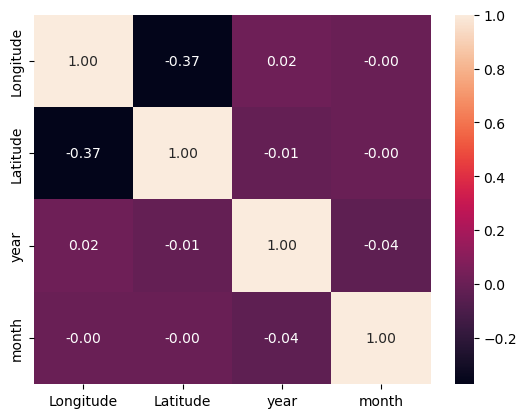

In [ ]:
# check if data is loaded correctly, obviously the diagonal should have all 1s as values, so it's correct
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()
# how strong is the correlation, 1 perfect positive relationship, -1 perferct inverse relationship and 0 not at all

In [ ]:
# filter for the 2 crime types that we are considering
df_filtered = df[
    df["Crime type"].isin([
        "Violence and sexual offences",
        "Anti-social behaviour"
    ])
]

In [9]:
df_sample = df_filtered.sample(5000) # reduce for now for better speed, comment this out in the future

In [10]:
#plt.figure(figsize=(10, 6))

#sns.kdeplot(
 #   data=df_filtered,
  ## y="Latitude",
    #fill=True,
    #cmap="Reds",
    #thresh=0.05
#)

#plt.title("Crime Density Heatmap")
#plt.show()

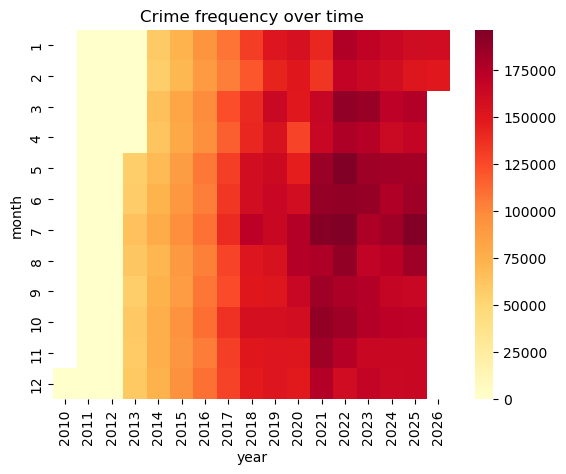

In [ ]:
# biased, as first 5000 entries are taken only, but definitely useful if considering the whole dataset
pivot = df_filtered.pivot_table(
    index="month",
    columns="year",
    values="Crime ID",
    aggfunc="count"
)

sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Crime frequency over time")
plt.show()

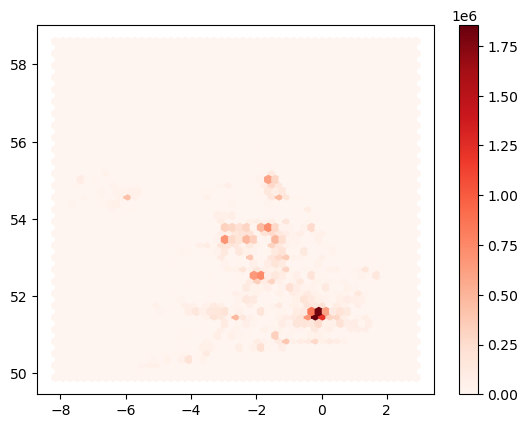

In [ ]:
# useful for finding clusters, but still need to identify LSOA for those clusters
plt.hexbin(
    df_filtered["Longitude"],
    df_filtered["Latitude"],
    gridsize=50,
    cmap="Reds"
)
plt.colorbar()
plt.show()
# x: west → east in UK as coordinates
# y: vertical pos on the map

In [ ]:
# if we wanna just check 1 crime type, and then maybe compare heatmaps or violin plots in the future
df_vio = df_filtered[df_filtered["Crime type"] == "Violence and sexual offences"]

lsoa_counts = (
    df_filtered
    .groupby("LSOA name")
    .size()
    .sort_values(ascending=False)
)

print(lsoa_counts.head(20))

LSOA name
Newcastle upon Tyne 024G    34343
Derby 013F                  31874
Leeds 111B                  31445
Westminster 018A            30415
Birmingham 138A             29231
Brighton and Hove 027A      25731
Newcastle upon Tyne 024H    23665
Liverpool 060C              23519
Bristol 032B                23394
Westminster 018C            22970
City of London 001F         22860
Gloucester 004F             22258
Hillingdon 031A             22197
Stoke-on-Trent 015D         22153
Blackpool 006A              21687
Manchester 055B             21442
Herefordshire 012C          20772
Swansea 025F                20437
Cardiff 032F                19858
Leicester 041A              19834
dtype: int64


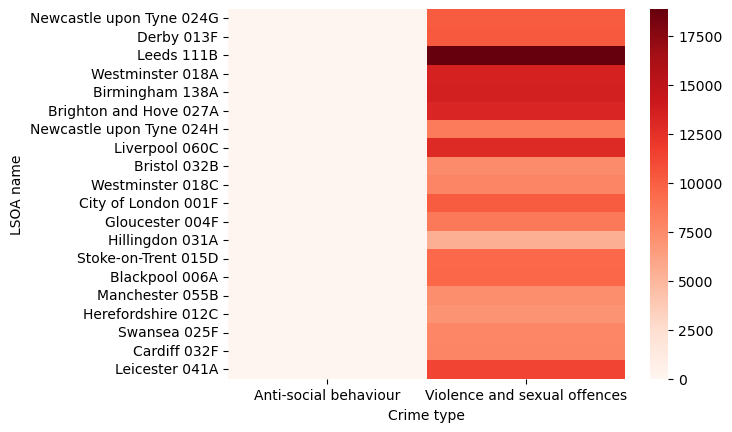

In [ ]:
#import seaborn as sns
#import matplotlib.pyplot as plt

#pivot = df_filtered.pivot_table(
#    index="LSOA name",
#    columns="Crime type",
#    values="Crime ID",
#    aggfunc="count",
#    fill_value=0
#)

# optional: limit to top 20 LSOAs for readability
#top_lsoas = lsoa_counts.head(20).index
#pivot = pivot.loc[top_lsoas]

#sns.heatmap(pivot, cmap="Reds")
#plt.show()

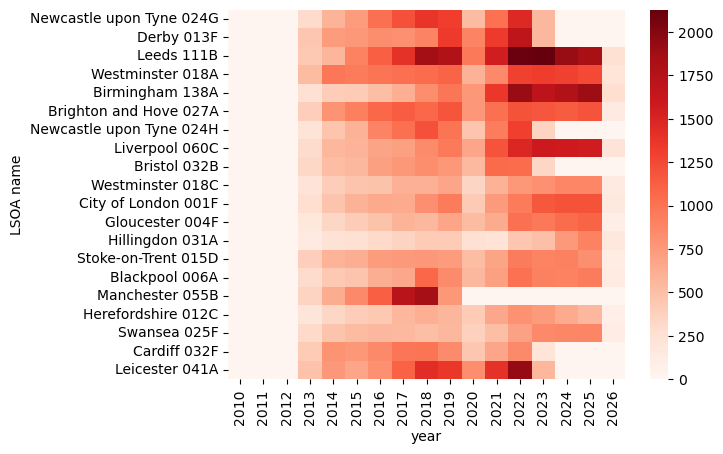

In [ ]:
# skewed data, only 5000 entries and it seems like not many of those are from 2010-2012
pivot_time = df_filtered.pivot_table(
    index="LSOA name",
    columns="year",
    values="Crime ID",
    aggfunc="count",
    fill_value=0
)

top_lsoas = lsoa_counts.head(20).index
sns.heatmap(pivot_time.loc[top_lsoas], cmap="Reds")
plt.show()

In [ ]:
# change weights in the future using Salih's model, but weight approach looks viable to me
weights = {
    "Violence and sexual offences": 2,
    "Anti-social behaviour": 1
} # example of giving different weights/severity to crimes, we could use the mathematical model here to predict actually, then make an interactive heatmap to show how police would be allocated compared to how it is now and how crime could be reduced

df_filtered["weight"] = df_filtered["Crime type"].map(weights)

lsoa_risk = (
    df_filtered
    .groupby("LSOA name")["weight"]
    .sum()
    .sort_values(ascending=False)
)

print(lsoa_risk.head(20))

C:\Users\danie\AppData\Local\Temp\ipykernel_8364\3711600793.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["weight"] = df_filtered["Crime type"].map(weights)


LSOA name
Leeds 111B                  69233
Birmingham 138A             58443
Westminster 018A            58223
Newcastle upon Tyne 024G    54577
Derby 013F                  52472
Brighton and Hove 027A      52195
Liverpool 060C              50117
City of London 001F         48376
Leicester 041A              42534
Newcastle upon Tyne 024H    41119
Stoke-on-Trent 015D         41107
Blackpool 006A              41035
Westminster 018C            40830
Gloucester 004F             39496
Bristol 032B                38334
Liverpool 061C              37474
Westminster 013B            37025
Swansea 025F                36251
Manchester 055B             36122
Cardiff 032F                35652
Name: weight, dtype: int64


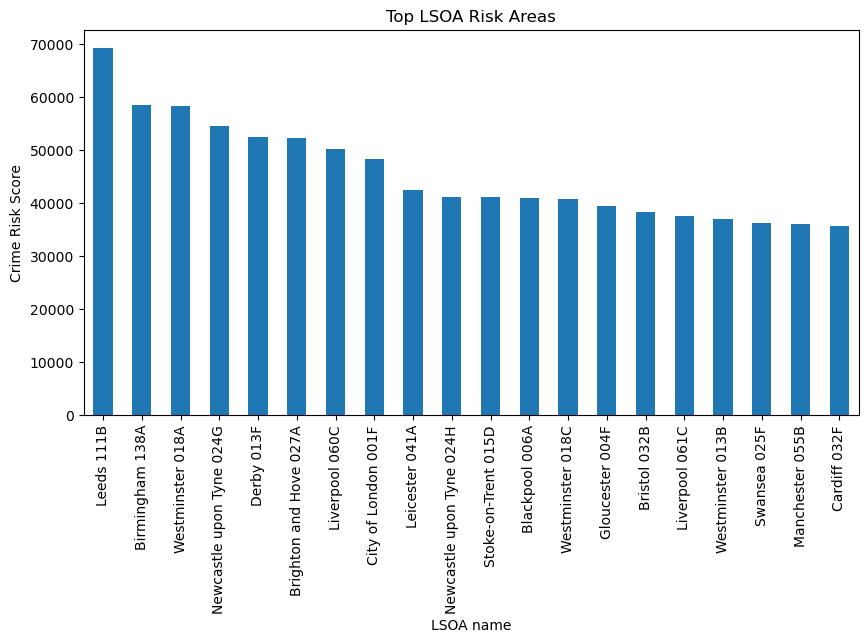

In [17]:
lsoa_risk.head(20).plot(kind="bar", figsize=(10,5))
plt.ylabel("Crime Risk Score")
plt.title("Top LSOA Risk Areas")
plt.show()

In [18]:
deprivation = pd.read_csv("deprivation.csv")


In [ ]:
# merge on LSOA code to add deprivation data to our main data frame
merged = df_filtered.merge(
    deprivation,
    left_on="LSOA code",
    right_on="LSOA code (2011)",
    how="inner"
)

In [ ]:
# crime count + IMD score for each LSOA, then calc correlation
crime_per_lsoa = (
    merged.groupby("LSOA code")
    .size()
    .reset_index(name="crime_count")
)

imd = deprivation[[
    "LSOA code (2011)",
    "Index of Multiple Deprivation (IMD) Score"
]]

analysis = crime_per_lsoa.merge(
    imd,
    left_on="LSOA code",
    right_on="LSOA code (2011)"
)

print(analysis.corr(numeric_only=True))

                                           crime_count  \
crime_count                                   1.000000   
Index of Multiple Deprivation (IMD) Score     0.454745   

                                           Index of Multiple Deprivation (IMD) Score  
crime_count                                                                 0.454745  
Index of Multiple Deprivation (IMD) Score                                   1.000000  


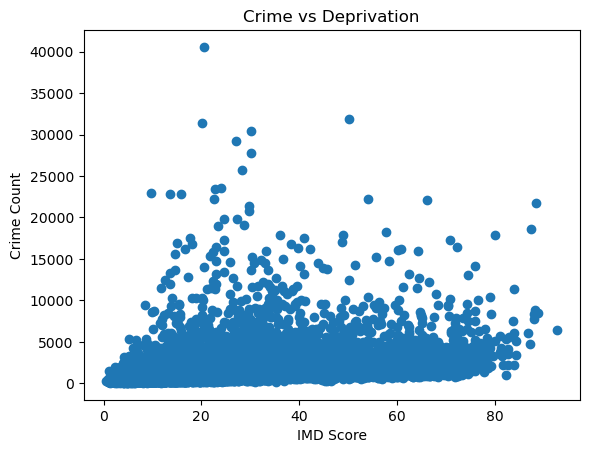

In [ ]:
# here we also graphically show the correlation calculated above
plt.scatter(
    analysis["Index of Multiple Deprivation (IMD) Score"],
    analysis["crime_count"]
)

plt.xlabel("IMD Score")
plt.ylabel("Crime Count")
plt.title("Crime vs Deprivation")
plt.show()

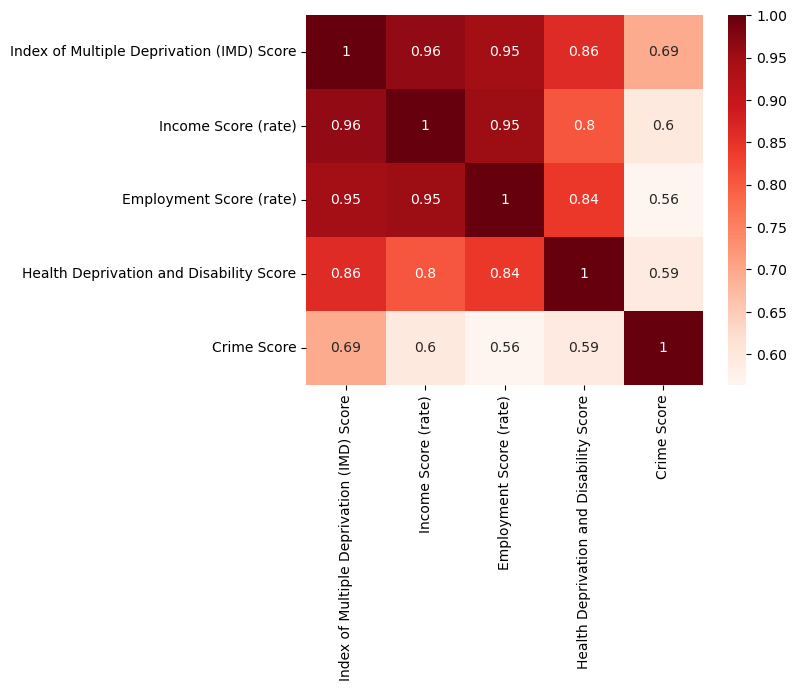

In [ ]:
# areas with high deprivation also experience high income deprivation, employment deprivation, health deprivation, and elevated crime scores.
#  The correlation is pretty strong and clear here. Therefore, we should definitely include the IMD in our model.
cols = [
    "Index of Multiple Deprivation (IMD) Score",
    "Income Score (rate)",
    "Employment Score (rate)",
    "Health Deprivation and Disability Score",
    "Crime Score"
]

corr = merged[cols].corr()

sns.heatmap(corr, annot=True, cmap="Reds")
plt.show()

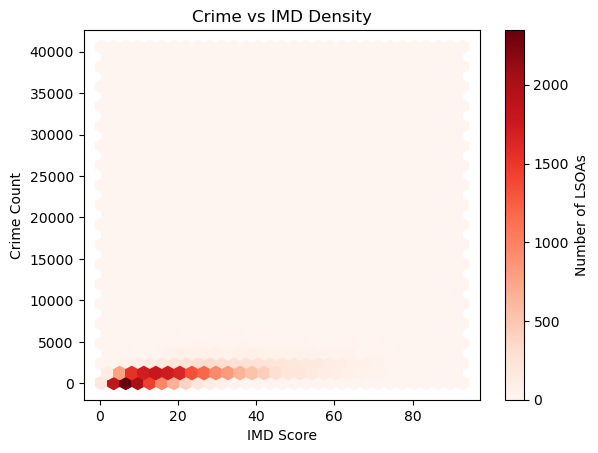

In [ ]:
# higher IMD score (more deprived area) -> more crime, this also shows visually the correlation but it also shows how many LSOAs are in this category/cluster 
plt.hexbin(
    analysis["Index of Multiple Deprivation (IMD) Score"],
    analysis["crime_count"],
    gridsize=30,
    cmap="Reds"
)

plt.xlabel("IMD Score")
plt.ylabel("Crime Count")
plt.title("Crime vs IMD Density")
plt.colorbar(label="Number of LSOAs")

plt.show()